In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
import time

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# Exploratory Data Analysis

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The Bank Marketing dataset consists of 41,188 observations and 21 variables.

The feature types are distributed as follows:
- 11 categorical features (object dtype), representing client attributes and campaign metadata
- 5 integer features, typically count‑based or encoded numeric fields
- 5 float features, mostly continuous numeric measures

This mix of categorical and numerical variables suggests that preprocessing will require both encoding strategies for categorical fields and scaling/normalization considerations for continuous ones.

In [6]:
df.duplicated().sum()

np.int64(12)

In [7]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [8]:
df.isna().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp.var.rate      False
cons.price.idx    False
cons.conf.idx     False
euribor3m         False
nr.employed       False
y                 False
dtype: bool

The dataset contains 12 duplicate rows, which can be safely removed, and no missing values across any of the 21 features.

In [9]:
df.y.value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

The distribution of the target variable is not balanced.
The positive class (clients who subscribed to the term deposit) occurs approximately four times less often than the negative class.
This imbalance will require careful handling during modeling, particularly for recall‑oriented tasks, through techniques such as class weighting, resampling, or threshold tuning.

In [10]:
for col in df.select_dtypes(include='object'):
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Column: loan
loan
no         33950
yes         6248
unknown      9

To better understand the categorical structure of the dataset, I examine the value counts for each object‑type feature. 

This helps identify rare categories, potential grouping opportunities, and the most appropriate preprocessing strategy for each variable.

Before diving into the categorical features, I first map the target column y to a binary format, assigning 1 to “yes” and 0 to “no”.

In [11]:
df["y_num"] = df["y"].map({"yes": 1, "no": 0})

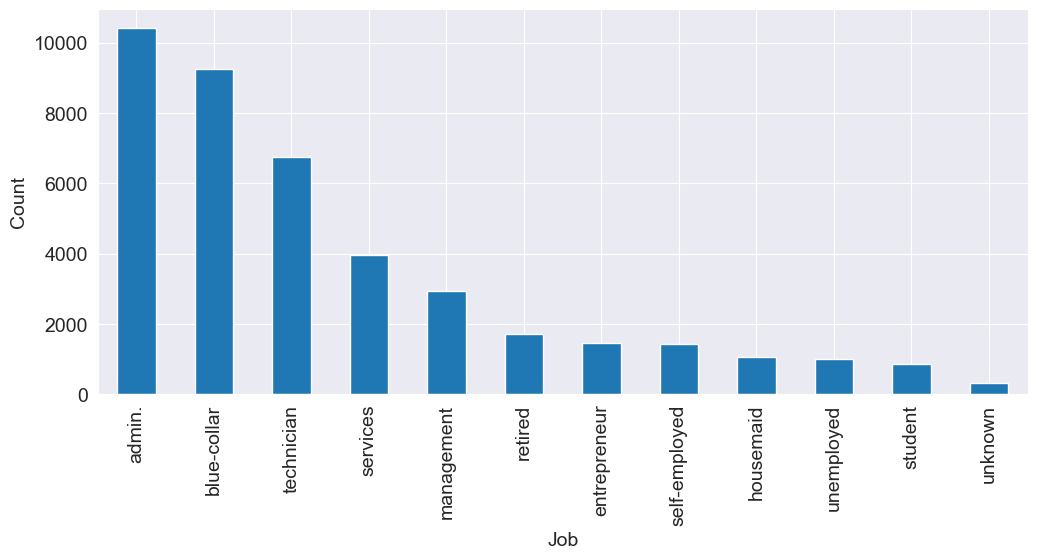

In [12]:
df.job.value_counts().plot(kind="bar", figsize=(12, 5))
plt.xlabel("Job")
plt.ylabel("Count")
plt.show();

In [13]:
df_job = (
    df.groupby("job")
      .agg(
          count_rows=('job', 'count'),
          mean_y = ('y_num', 'mean'),
          mean_emp_var_rate=('emp.var.rate', 'mean'),
          mean_euribor3m=('euribor3m', 'mean'),
          mean_nr_employed=('nr.employed', 'mean'),
          mean_cons_price_idx=('cons.price.idx', 'mean'),
          mean_cons_conf_idx=('cons.conf.idx', 'mean')
      )
      .reset_index()
)
df_job

,job,count_rows,mean_y,mean_emp_var_rate,mean_euribor3m,mean_nr_employed,mean_cons_price_idx,mean_cons_conf_idx
0,admin.,10422,0.129726,0.015563,3.550274,5164.125350,93.534054,-40.245433
1,blue-collar,9254,0.068943,0.248995,3.771996,5175.615150,93.656656,-41.375816
2,entrepreneur,1456,0.085165,0.158723,3.791120,5176.313530,93.605372,-41.283654
3,housemaid,1060,0.100000,0.433396,4.009645,5179.529623,93.676576,-39.495283
4,management,2924,0.112175,-0.012688,3.611316,5166.650513,93.522755,-40.489466
5,retired,1720,0.252326,-0.698314,2.770066,5122.262151,93.430786,-38.573081
6,self-employed,1421,0.104856,0.094159,3.689376,5170.674384,93.559982,-40.488107
7,services,3969,0.081381,0.175359,3.699187,5171.600126,93.634659,-41.290048
8,student,875,0.314286,-1.408000,1.884224,5085.939086,93.331613,-40.187543
9,technician,6743,0.108260,0.274566,3.820401,5175.648391,93.561471,-39.927569


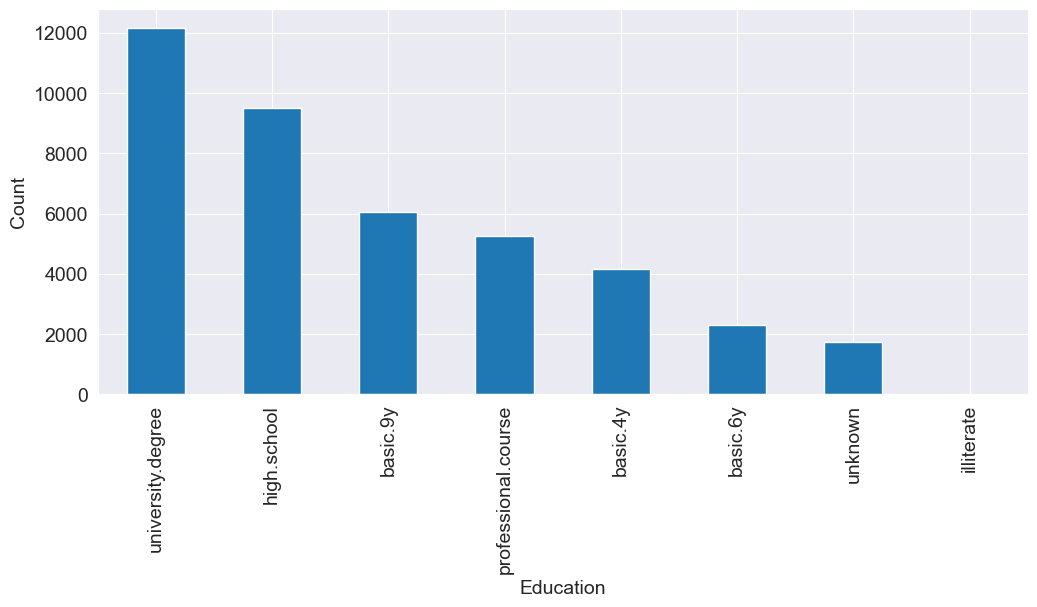

In [14]:
df.education.value_counts().plot(kind="bar", figsize=(12, 5))
plt.xlabel("Education")
plt.ylabel("Count")
plt.show();

The job and education features show a diverse set of categories with uneven distributions. Although some categories are more frequent than others, the overall number of unique values remains moderate. Because of this, there is no strong need to collapse or merge categories at this stage. Preserving the original variation may help the model capture subtle behavioral patterns associated with specific professions or education levels.

In [15]:
df_marital= (
    df.groupby("marital")
      .agg(
          count_rows=('marital', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_marital

,marital,count_rows,mean_y
0,divorced,4612,0.103209
1,married,24928,0.101573
2,single,11568,0.140041
3,unknown,80,0.150000


In [16]:
df_contact= (
    df.groupby("contact")
      .agg(
          count_rows=('contact', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_contact

,contact,count_rows,mean_y
0,cellular,26144,0.147376
1,telephone,15044,0.052313


In [17]:
df_default = (
    df.groupby("default")
      .agg(
          count_rows=('default', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_default

,default,count_rows,mean_y
0,no,32588,0.12879
1,unknown,8597,0.05153
2,yes,3,0.00000


In [18]:
df_loan= (
    df.groupby("loan")
      .agg(
          count_rows=('loan', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_loan

,loan,count_rows,mean_y
0,no,33950,0.113402
1,unknown,990,0.108081
2,yes,6248,0.109315


In [19]:
df_housing= (
    df.groupby("housing")
      .agg(
          count_rows=('housing', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_housing

,housing,count_rows,mean_y
0,no,18622,0.108796
1,unknown,990,0.108081
2,yes,21576,0.116194


In [20]:
df_poutcome= (
    df.groupby("poutcome")
      .agg(
          count_rows=('poutcome', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_poutcome

,poutcome,count_rows,mean_y
0,failure,4252,0.142286
1,nonexistent,35563,0.088322
2,success,1373,0.651129


The default feature contains almost no meaningful variation: only 3 records are labeled “yes”, and none of them correspond to a positive target. The remaining values are “no” or “unknown”. Given this extremely low signal and near‑constant distribution, the feature is unlikely to contribute to model performance and can be safely removed.

All other categorical features appear sufficiently informative to retain

In [21]:
df["month_num"] = pd.to_datetime(df['month'], format="%b").dt.month

In [22]:
mapping_day = {"mon":0, "tue":1, "wed":2, "thu":3, "fri":4, "sat":5, "sun":6}
df["day_of_week_num"] = df["day_of_week"].map(mapping_day)

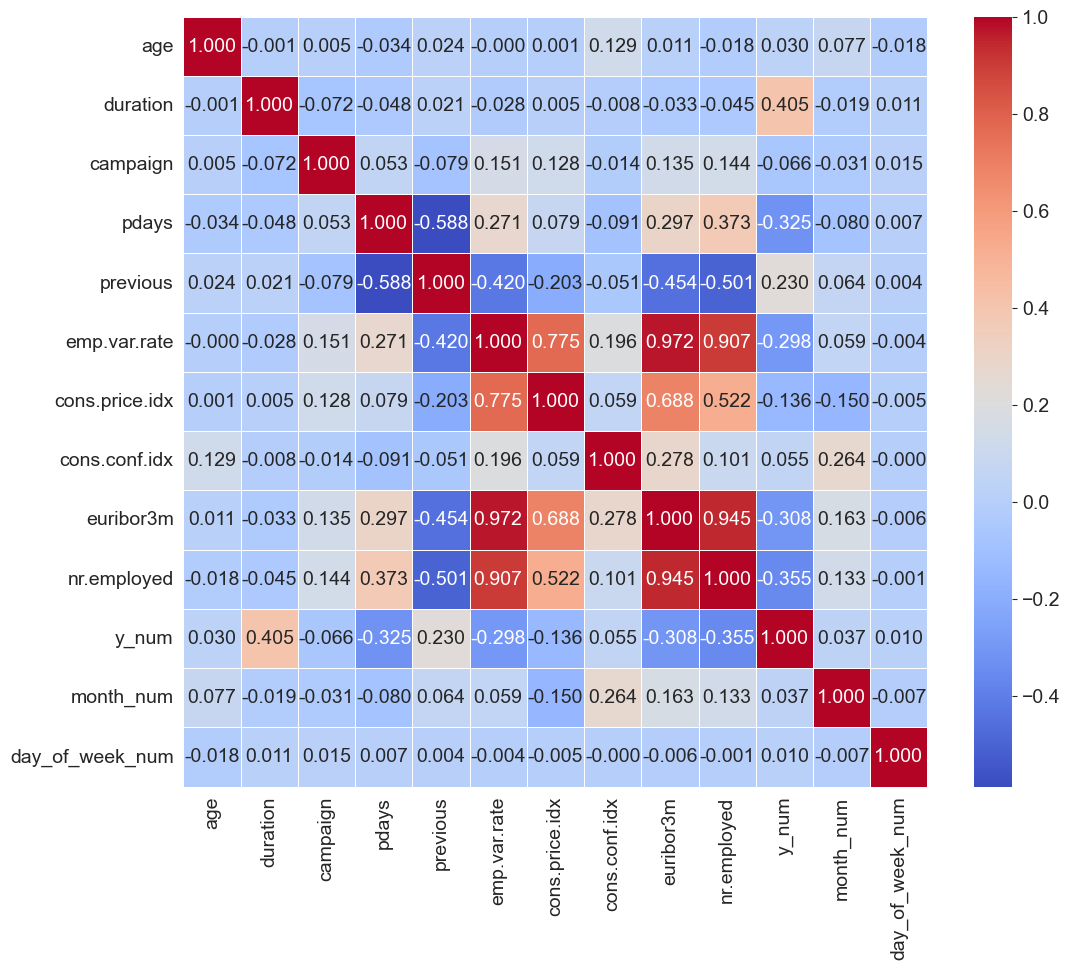

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.show()

The correlation heatmap shows that duration has the strongest correlation with the target variable. However, this feature must be removed because it introduces data leakage, its value is only known after the call is completed, making it unusable for predictive modeling.

Beyond duration, the correlations with the target are generally weak. The most notable relationships come from macro‑economic indicators and the campaign‑related variables pdays and previous. These features reflect whether the client was contacted before, indicating that engagement in previous campaigns plays a meaningful role in predicting subscription likelihood.

In [24]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,month_num,day_of_week_num
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654,6.607896,1.979581
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173,2.040998,1.411514
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,3.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,5.000000,1.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,6.000000,2.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,8.000000,3.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,12.000000,4.000000


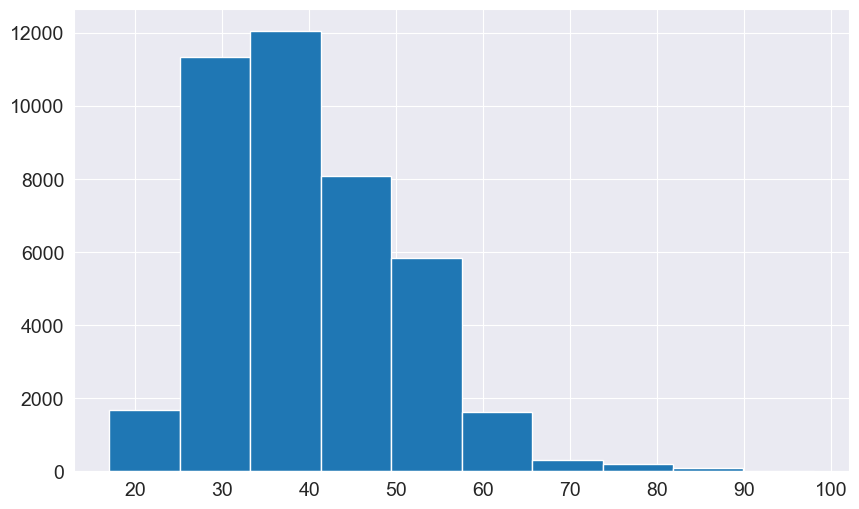

In [25]:
df.age.hist()
plt.show()

In [26]:
bins = [12, 25, 35, 50, 100]
labels = ["young adult", "adult", "mid-age", "senior"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

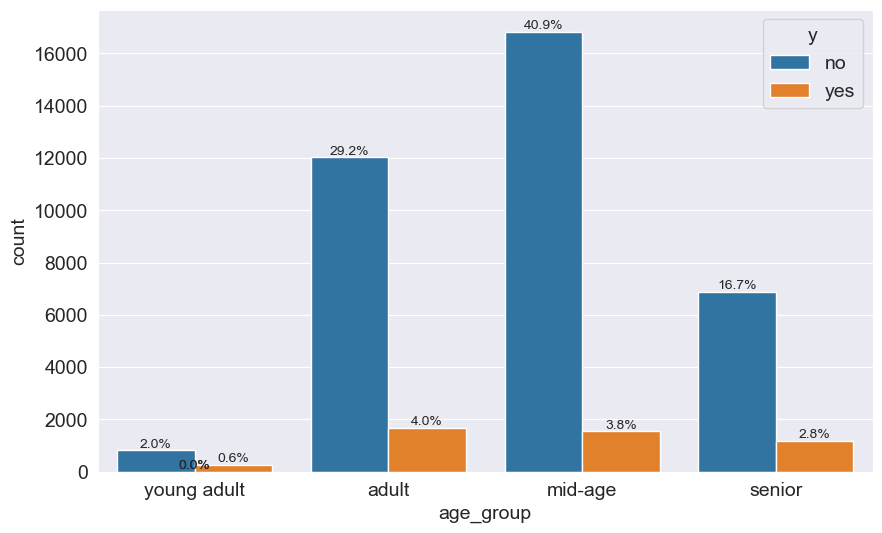

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="age_group", hue="y")

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    ax.annotate(f"{percent:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

In [28]:
df_summary = (
    df.groupby("age_group", observed=False)
      .agg(
          count_rows=('age', 'count'),
          mean_y = ('y_num', 'mean'),
          mean_emp_var_rate=('emp.var.rate', 'mean'),
          mean_cons_price_idx=('cons.price.idx', 'mean'),
          mean_cons_conf_idx=('cons.conf.idx', 'mean'),
          mean_euribor3m=('euribor3m', 'mean'),
          mean_nr_employed=('nr.employed', 'mean')
      )
      .reset_index()
)

display(df_summary);

,age_group,count_rows,mean_y,mean_emp_var_rate,mean_cons_price_idx,mean_cons_conf_idx,mean_euribor3m,mean_nr_employed
0,young adult,1068,0.239700,-0.828184,93.440772,-41.340918,2.524922,5119.845599
1,adult,13686,0.121730,-0.022717,93.541217,-40.922753,3.481400,5162.624689
2,mid-age,18379,0.084281,0.241205,93.614744,-40.546303,3.809323,5175.384384
3,senior,8055,0.145127,0.016760,93.562910,-39.577865,3.575309,5161.739156


The age feature is unevenly distributed: young adults and seniors are under‑represented, while most clients are adults and middle‑aged. Despite their smaller counts, younger and older clients show higher subscription rates, whereas middle‑aged clients have the lowest, making them the hardest group to convert. 

This creates a U‑shaped relationship, suggesting that age carries meaningful predictive signal and may benefit models capable of capturing non‑linear patterns

In [29]:
df_month = (
    df.groupby("month_num")
      .agg(
          count_rows=('month_num', 'count'),
          mean_y = ('y_num', 'mean'),
          mean_emp_var_rate=('emp.var.rate', 'mean'),
          mean_cons_price_idx=('cons.price.idx', 'mean'),
          mean_cons_conf_idx=('cons.conf.idx', 'mean'),
          mean_euribor3m=('euribor3m', 'mean'),
          mean_nr_employed=('nr.employed', 'mean')
      )
      .reset_index()
)

df_month

,month_num,count_rows,mean_y,mean_emp_var_rate,mean_cons_price_idx,mean_cons_conf_idx,mean_euribor3m,mean_nr_employed
0,3,546,0.505495,-1.800000,93.097330,-42.650549,1.162745,5055.390110
1,4,2632,0.204787,-1.800000,93.119558,-46.273632,1.361070,5093.123708
2,5,13769,0.064347,-0.164972,93.528882,-40.579272,3.293665,5149.521592
3,6,5318,0.105115,0.688379,94.245402,-41.579428,4.256908,5197.493193
4,7,7174,0.090466,1.158921,93.894923,-42.370170,4.685678,5214.078575
5,8,6178,0.106021,0.747151,93.311065,-35.597184,4.300623,5200.248349
6,9,570,0.449123,-2.177368,93.346474,-33.893158,0.834760,4988.847895
7,10,718,0.438719,-2.438579,93.175107,-34.580919,1.200123,5018.823816
8,11,4101,0.101439,-0.418483,93.200943,-41.238747,3.723123,5173.031236
9,12,182,0.489011,-2.846154,92.715363,-33.708791,0.865319,5031.895604


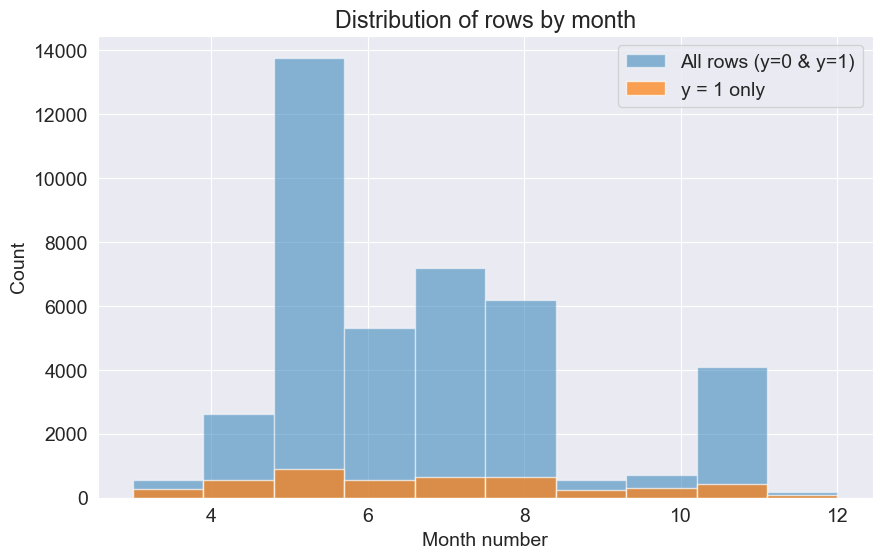

In [30]:
plt.figure(figsize=(10,6))

plt.hist(df['month_num'], bins=10, alpha=0.5, label='All rows (y=0 & y=1)')
plt.hist(df.loc[df['y_num'] == 1, 'month_num'], 
         bins=10, alpha=0.7, label='y = 1 only')

plt.xlabel("Month number")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of rows by month")
plt.show()

The month feature shows a highly uneven distribution: some months contain only a small number of contacts but have a high conversion rate, while others include many contacts yet show very low success rates. This imbalance makes the month‑based patterns difficult to predict directly. The model will need to learn the underlying seasonality to reproduce these trends reliably in future predictions.

In [31]:
df_day = (
    df.groupby(["day_of_week"])
      .agg(
          count_rows=('day_of_week', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_day

,day_of_week,count_rows,mean_y
0,fri,7827,0.108087
1,mon,8514,0.099483
2,thu,8623,0.121188
3,tue,8090,0.117800
4,wed,8134,0.116671


There is a slight increase in the conversion rate toward the middle of the week. 

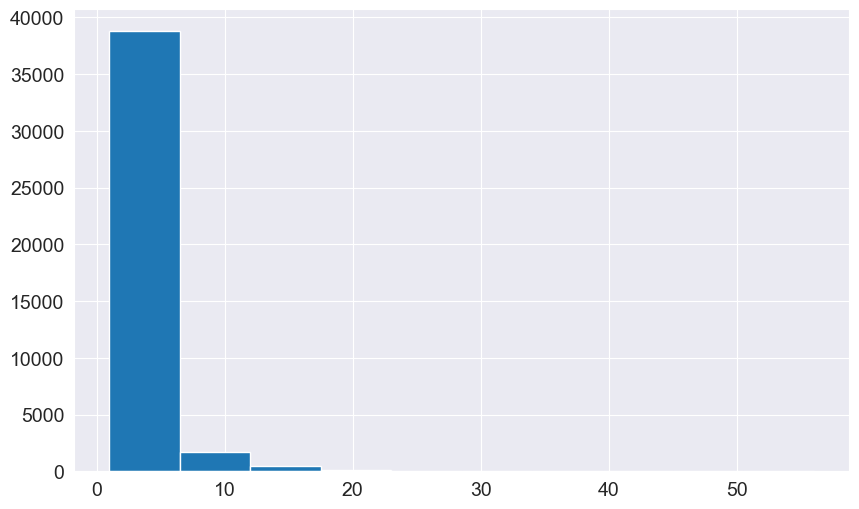

In [32]:
df.campaign.hist()
plt.show()

In [33]:
df.campaign.describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

In [34]:
df[df.campaign>20].campaign.count()

np.int64(157)

In [35]:
bins = [1, 2, 3, 20, 60]
labels = ["1-2", "2-3", "3-20", "20+"]

df["campaign_group"] = pd.cut(df["campaign"], bins=bins, labels=labels, right=False)

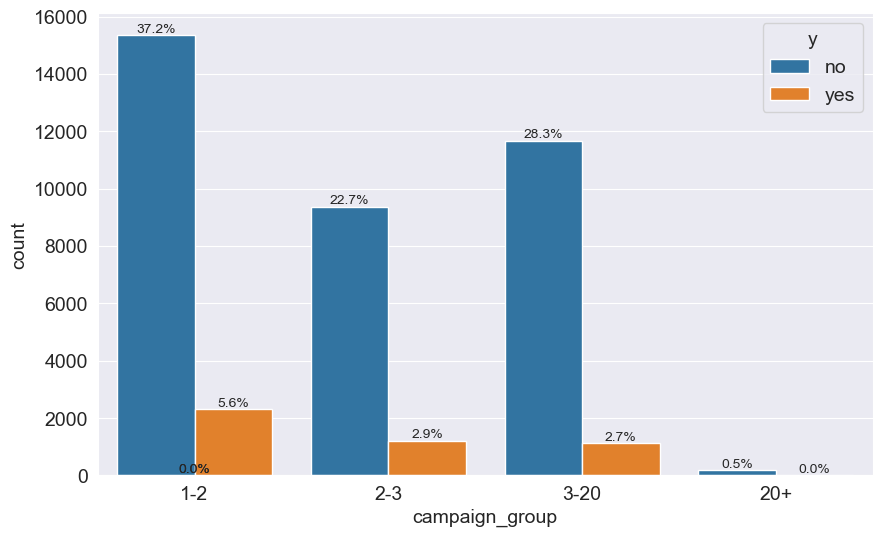

In [36]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="campaign_group", hue="y")

# obliczamy procenty
total = len(df)

for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    ax.annotate(f"{percent:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show();

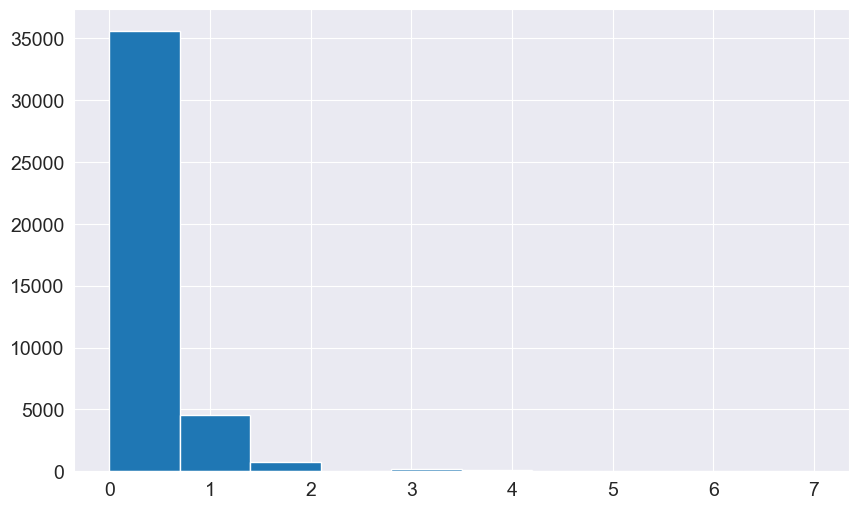

In [37]:
df.previous.hist()
plt.show()

In [38]:
df.previous.describe()

count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

In [39]:
df[df.previous>3].previous.count()

np.int64(94)

In [40]:
bins = [0, 1, 2, 3, 7]
labels = ["0-1", "1-2", "2-3", "3-7"]

df["previous_group"] = pd.cut(df["previous"], bins=bins, labels=labels, right=False)

In [41]:
df_pre= (
    df.groupby("previous_group", observed=False)
      .agg(
          count_rows=('previous_group', 'count'),
          mean_y = ('y_num', 'mean')
      )
      .reset_index()
)

df_pre

,previous_group,count_rows,mean_y
0,0-1,35563,0.088322
1,1-2,4561,0.212015
2,2-3,754,0.464191
3,3-7,309,0.588997


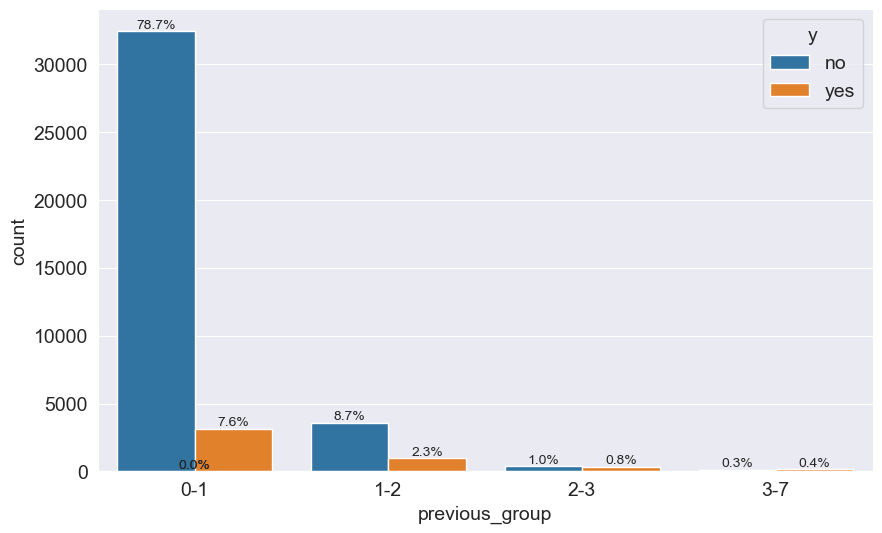

In [42]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="previous_group", hue="y")

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    ax.annotate(f"{percent:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show();

Both campaign and previous show long right‑tailed distributions with a few extreme values. Most clients were contacted once or not at all, while only a small minority experienced many contact attempts. These outliers create a highly skewed distribution, but they also reflect real campaign behavior and may carry useful signal for modeling.

In [43]:
df[df["pdays"].isin([999])].pdays.count()

np.int64(39673)

In [44]:
df[df.pdays<100].pdays.count()

np.int64(1515)

In [45]:
df["was_contacted_before"] = (df["pdays"] != 999).astype(int)

Most records have pdays = 999, which indicates that the client was not contacted in the previous campaign. Because this value dominates the distribution, it is more meaningful to transform pdays into a binary feature that simply captures whether the client was contacted before. This preserves the useful information while avoiding the distortion caused by the artificial 999 value

In [46]:
df.select_dtypes(include='float').nunique()

emp.var.rate       10
cons.price.idx     26
cons.conf.idx      26
euribor3m         316
nr.employed        11
dtype: int64

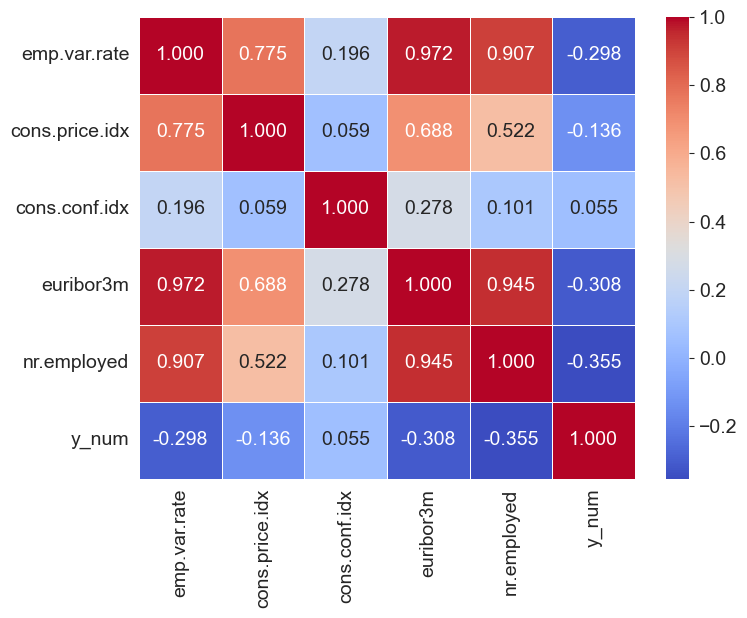

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y_num"]].corr(),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.show()

In [48]:
df.groupby('y')[["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]].mean()

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,
no,0.248875,93.603757,-40.593097,3.811491,5176.166600
yes,-1.233448,93.354386,-39.789784,2.123135,5095.115991


In [49]:
df[["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]].describe()

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,1.570960,0.578840,4.628198,1.734447,72.251528
min,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,1.400000,94.767000,-26.900000,5.045000,5228.100000


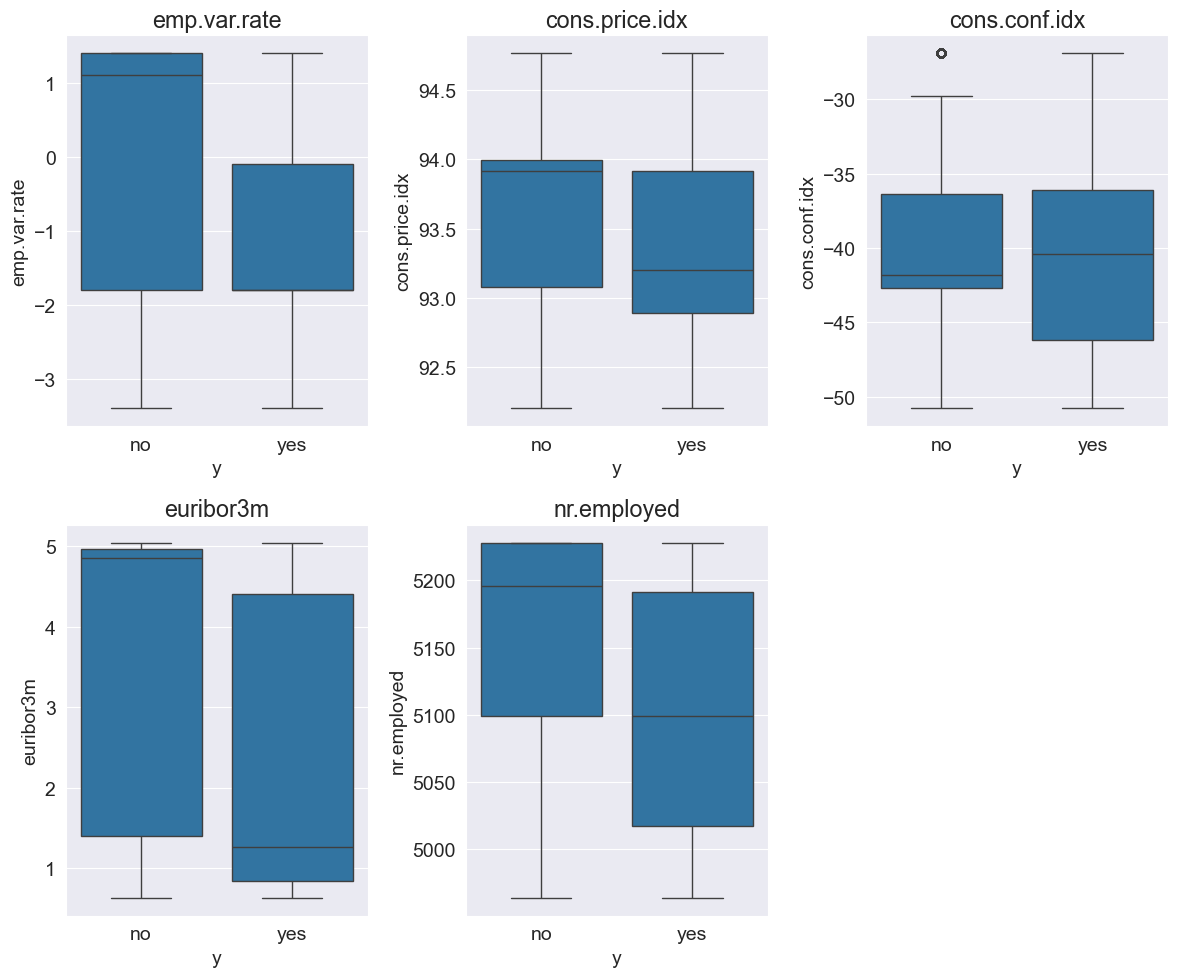

In [50]:
cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx",
        "euribor3m", "nr.employed"]

plt.figure(figsize=(12, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='y', y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

The social‑economic features show the strongest correlations with the target, and they likely influence client behavior differently depending on age, employment status, and overall financial context. Even though these variables are also highly correlated with each other, they capture distinct aspects of the economic environment. Because of this and given the clear non‑linear patterns in the dataset - it is reasonable to keep all of them and rely on models that can handle multicollinearity and non‑linear relationships, such as tree‑based methods or boosted ensembles.

## Conclusion

**Key EDA Insights**
1) Target imbalance: The positive class is ~4× smaller than the negative, requiring metrics and methods that handle imbalance.
2) Categorical features: "default" is almost constant - remove. Other categorical features show meaningful variation and should be kept.
3) Age: Uneven distribution with a U‑shaped conversion pattern - younger and older clients convert more, middle‑aged convert least.
4) Temporal features: Strong seasonality across months (uneven sample sizes and conversion rates). Slightly higher conversion mid‑week.
5) Campaign history features (pdays, previous, campaign): Highly skewed with long right tails."pdays" = 999 dominates - convert to a binary “contacted before” feature.
6) Socio‑economic indicators: Show the strongest correlations with the target. Correlated with each other but still informative; keep all.

**Chosen Metric: F1**

F1 is the most appropriate metric because:
- The dataset is highly imbalanced.
- Both Precision (avoid unnecessary contacts) and Recall (don’t miss potential subscribers) matter.
- F1 balances both and avoids misleading results that accuracy would produce.

**Imbalance Handling Strategy**

Because the train–test split must be time‑based (by month) to preserve seasonality, resampling methods like SMOTE or undersampling better to be avoided - they distort temporal patterns.

Instead, I plan to use:
- Class weighting - increases importance of the minority class without altering data order.
- Threshold tuning - optimizes the Precision-Recall balance and maximizes F1.

**Modeling Methods and Techniques**
- Tree‑based models (XGBoost, LightGBM, Random Forest)
- Handle non‑linear patterns, multicollinearity, and mixed feature types.
- Work well with imbalanced data when combined with class weighting.
- Logistic Regression useful as a baseline with proper encoding.